In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

# Notebookをどこから開いても，同じ作業フォルダとデータフォルダを参照する．
# PROJECT_DIR = Path.home() / "applied_programming_ii" / "01"
# DATA_DIR = Path.home() / "applied_programming_ii" / "data"
# FIGURE_DIR = PROJECT_DIR / "reports" / "figures"
PROJECT_DIR = Path(".")
DATA_DIR = Path("../../data")
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("作業フォルダ:", PROJECT_DIR)
print("データフォルダ:", DATA_DIR)
print("人口データの有無:", (DATA_DIR / "population_japan.csv").exists())

NumPy: 2.0.2
pandas: 2.3.3
作業フォルダ: .
データフォルダ: ../../data
人口データの有無: True


In [7]:
population = pd.read_csv(DATA_DIR / "population_japan.csv")

# 単位を千人から万人に直した列を追加する．
population["population_10k"] = population["total_population_thousand"] / 10

print(population.head())
print(population.tail())
print("期間:", population["year"].min(), "〜", population["year"].max(), " 行数:", len(population))

   year  total_population_thousand    note  population_10k
0  1920                      55963  census          5596.3
1  1921                      56666     NaN          5666.6
2  1922                      57390     NaN          5739.0
3  1923                      58119     NaN          5811.9
4  1924                      58876     NaN          5887.6
     year  total_population_thousand    note  population_10k
96   2016                     127042     NaN         12704.2
97   2017                     126919     NaN         12691.9
98   2018                     126749     NaN         12674.9
99   2019                     126555     NaN         12655.5
100  2020                     126146  census         12614.6
期間: 1920 〜 2020  行数: 101


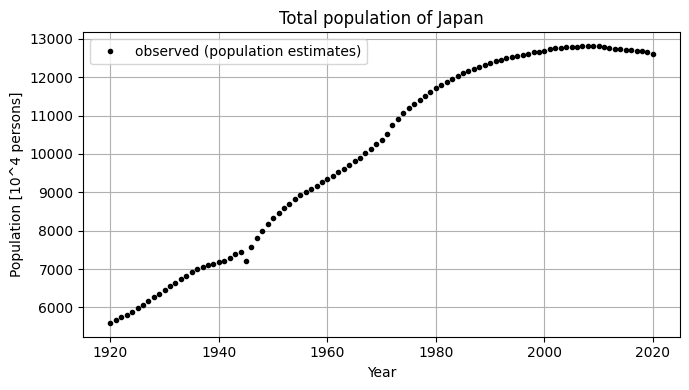

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(population["year"], population["population_10k"], color="black", marker="o", markersize=3, linestyle="none", label="observed (population estimates)")
ax.set_title("Total population of Japan")
ax.set_xlabel("Year")
ax.set_ylabel("Population [10^4 persons]")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "population_observed.png", dpi=150)
plt.show()